# Assignment 2: Model Interpretability

## Problem 2.1 SHAP Analysis

In [6]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

### Loading Dataset

In [7]:
# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age","workclass","fnlwgt","education","education-num","marital-status",
    "occupation","relationship","race","sex","capital-gain","capital-loss",
    "hours-per-week","native-country","income"
]

df = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)

# Drop missing values
df.dropna(inplace=True)

# Encode categorical features
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Split features & target
X = df.drop("income", axis=1)
y = df["income"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Training Model

In [8]:
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

print("Model accuracy:", model.score(X_test, y_test))

Model accuracy: 0.8608935974205435


### SHAP

In [9]:
# Sample data for speed
X_sample = shap.sample(X_test, 200, random_state=42)

# Create explainer
explainer = shap.Explainer(model, X_train)

# Compute SHAP values
shap_values = explainer(X_sample)

 97%|=================== | 387/400 [00:15<00:00]       

### Plots

#### Top 5 Most Important Features

In [12]:
# Extract SHAP values for class 1
shap_vals_class1 = shap_values.values[:, :, 1]

# Compute importance
importance = np.abs(shap_vals_class1).mean(axis=0)

feature_importance = pd.Series(importance, index=X.columns)
top5 = feature_importance.sort_values(ascending=False).head(5)

print("Top 5 Features:\n", top5)

Top 5 Features:
 relationship      0.066327
education-num     0.059201
marital-status    0.057366
age               0.053725
capital-gain      0.052165
dtype: float64


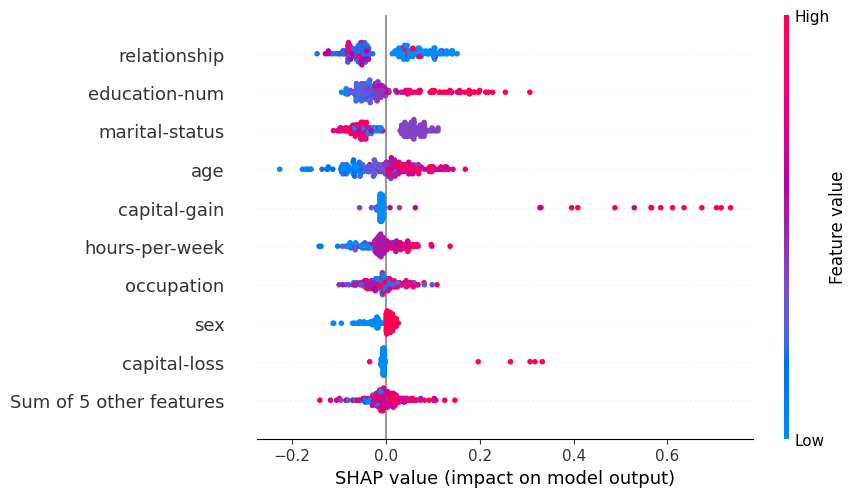

In [14]:
# Select class 1 (e.g., income >50K)
shap_values_class1 = shap_values[:, :, 1]

# Beeswarm plot
shap.plots.beeswarm(shap_values_class1)

#### Dependence Plot

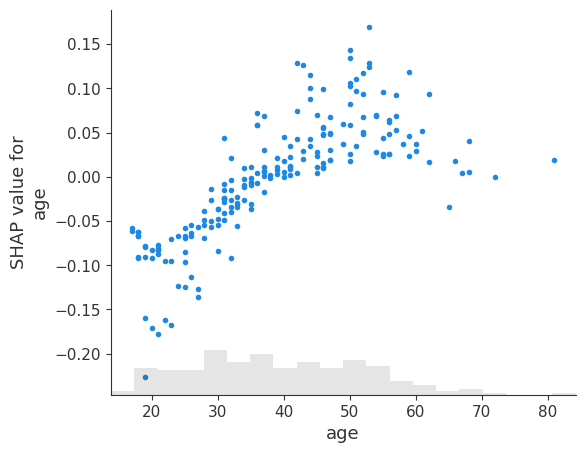

In [15]:
shap.plots.scatter(shap_values_class1[:, "age"])

#### Force Plot

In [19]:
shap.plots.force(shap_values_class1[0])

#### Predictions for 3 specific individuals with different incomes


--- Individual 0 ---
Prediction: 0


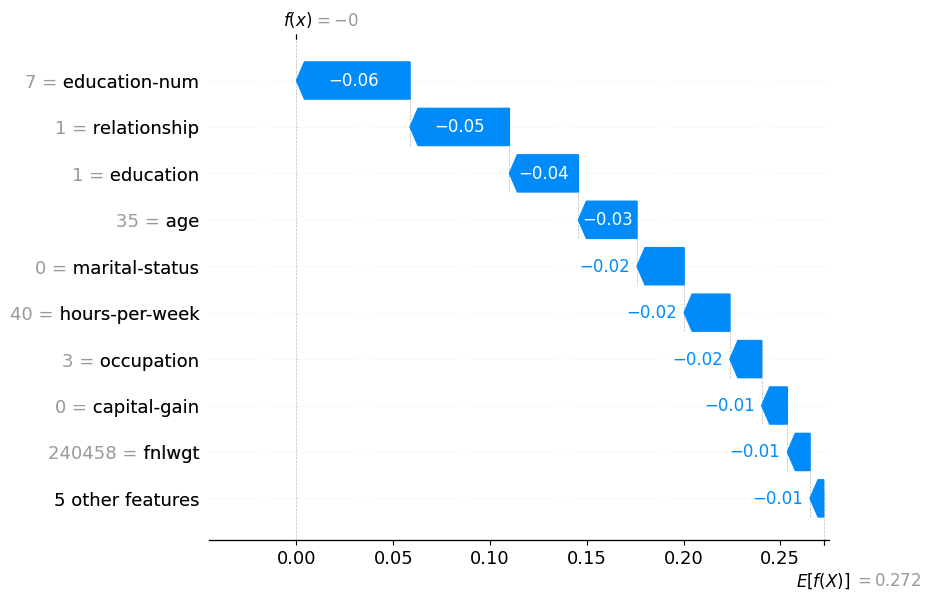


--- Individual 1 ---
Prediction: 0


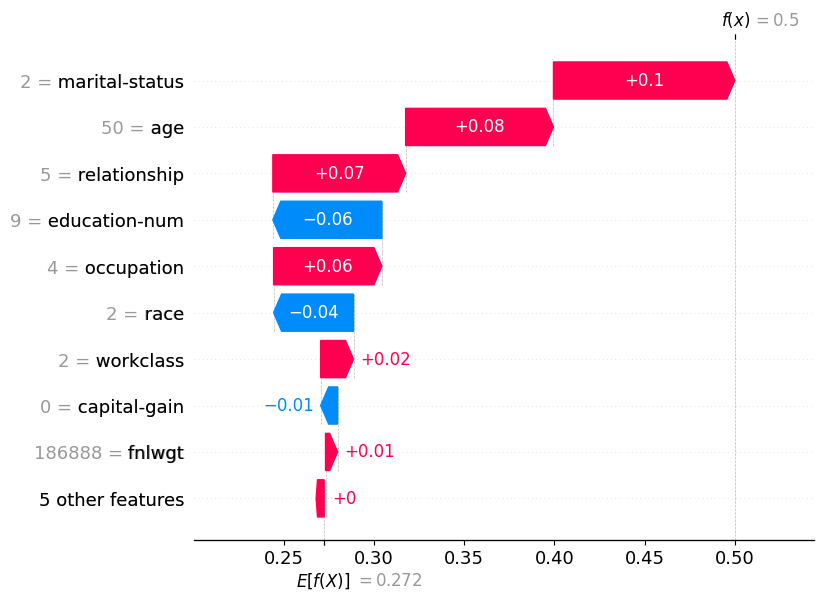


--- Individual 2 ---
Prediction: 1


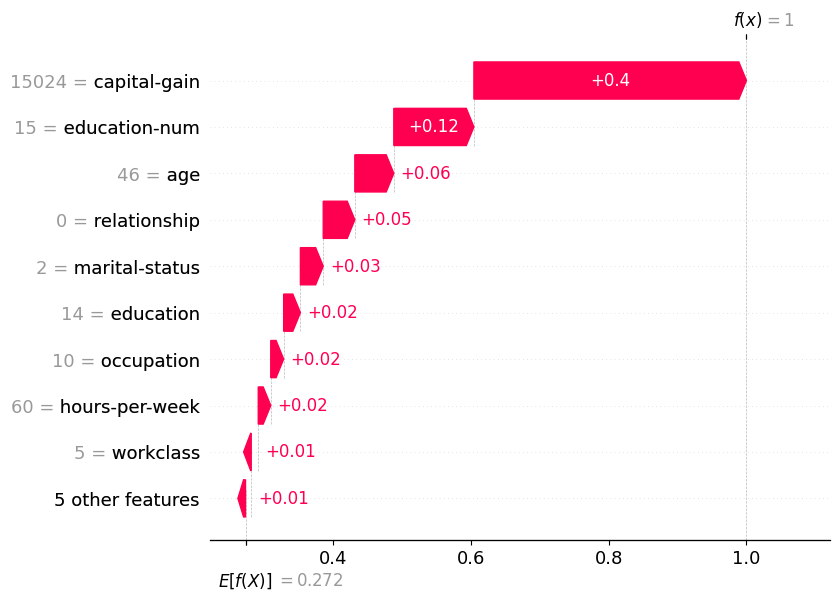

In [21]:
# Select class 1 (important!)
shap_values_class1 = shap_values[:, :, 1]

# Explain 3 individuals
indices = [0, 1, 2]

for i in indices:
    print(f"\n--- Individual {i} ---")
    print("Prediction:", model.predict(X_sample.iloc[[i]])[0])
    
    # Waterfall plot (correct)
    shap.plots.waterfall(shap_values_class1[i])

## Problem 2.2: LIME for Image Classification

### Imports

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms
from lime import lime_image
from skimage.segmentation import mark_boundaries

### Loading Pre-trained ResNet Model

In [3]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### Image Preprocessing

In [5]:
# ImageNet normalization
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Prediction Function for LIME

In [6]:
def predict_fn(images):
    model_input = torch.stack([
        transform(Image.fromarray(img)) for img in images
    ], dim=0)

    with torch.no_grad():
        outputs = model(model_input)
        probs = torch.nn.functional.softmax(outputs, dim=1)

    return probs.numpy()

### Load Images

In [7]:
image_paths = [
    "dog.jpg",
    "cat.jpg",
    "flower.jpg",
    "avocado.jpg",
    "car.jpg"
]

### Class Labels (ImageNet)

In [8]:
import json
import urllib.request

# Load ImageNet labels
url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
class_idx = json.load(urllib.request.urlopen(url))

idx2label = {int(k): v[1] for k, v in class_idx.items()}

### Applying LIME to all images

#### Running with 50 samples only

Images:   0%|          | 0/5 [00:00<?, ?it/s]


Loading dog.jpg...
Running LIME...


  0%|          | 0/50 [00:00<?, ?it/s]

Done!
Predicted: Samoyed


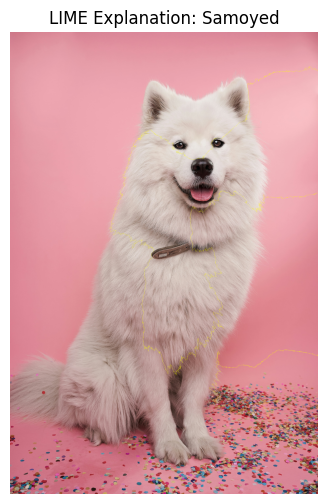


Loading cat.jpg...
Running LIME...


  0%|          | 0/50 [00:00<?, ?it/s]

Done!
Predicted: tiger_cat


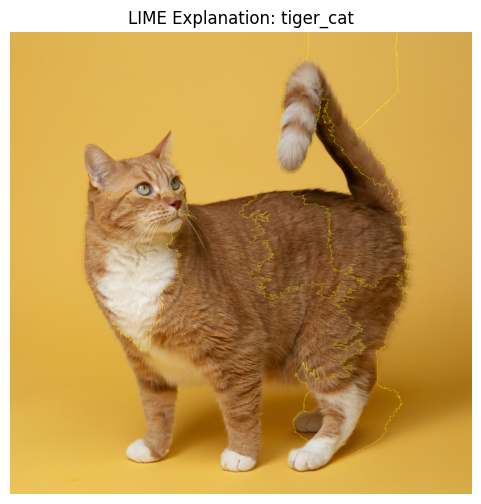


Loading flower.jpg...
Running LIME...


  0%|          | 0/50 [00:00<?, ?it/s]

Done!
Predicted: vase


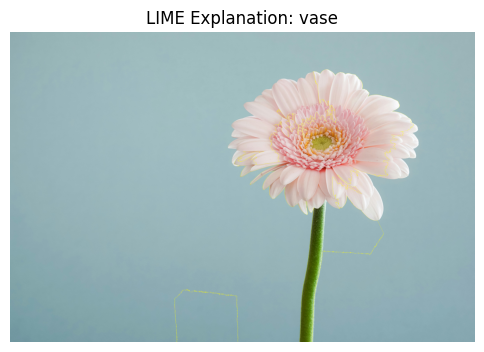


Loading avocado.jpg...
Running LIME...


  0%|          | 0/50 [00:00<?, ?it/s]

Done!
Predicted: cucumber


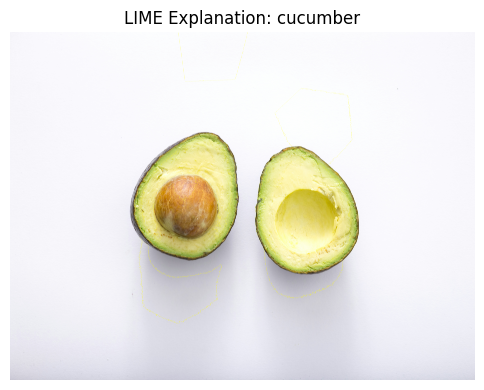


Loading car.jpg...
Running LIME...


  0%|          | 0/50 [00:00<?, ?it/s]

Done!
Predicted: minivan


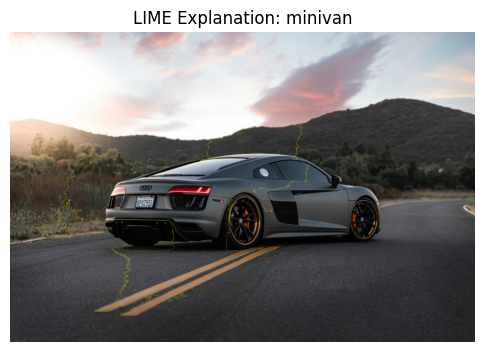

In [10]:
from tqdm.notebook import tqdm
from lime import lime_image
from skimage.segmentation import slic

explainer = lime_image.LimeImageExplainer()

for path in tqdm(image_paths, desc="Images"):

    print(f"\nLoading {path}...")
    img = np.array(Image.open(path).convert("RGB"))

    print("Running LIME...")
    explanation = explainer.explain_instance(
        img,
        predict_fn,
        top_labels=3,
        num_samples=50,
        segmentation_fn=lambda x: slic(x, n_segments=50)
    )

    print("Done!")
    
    
    # Get top prediction
    top_label = explanation.top_labels[0]
    print("Predicted:", idx2label[top_label])
    
    # Get explanation mask
    temp, mask = explanation.get_image_and_mask(
        top_label,
        positive_only=True,
        num_features=5,
        hide_rest=False
    )
    
    # Plot
    plt.figure(figsize=(6,6))
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME Explanation: {idx2label[top_label]}")
    plt.axis('off')
    plt.show()

#### Running with 500 samples

Images:   0%|          | 0/5 [00:00<?, ?it/s]


Loading dog.jpg...
Running LIME...


  0%|          | 0/500 [00:00<?, ?it/s]

Done!
Predicted: Samoyed


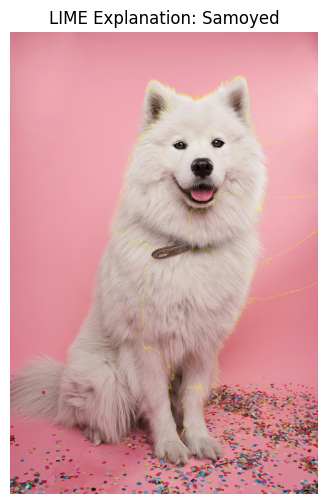


Loading cat.jpg...
Running LIME...


  0%|          | 0/500 [00:00<?, ?it/s]

Done!
Predicted: tiger_cat


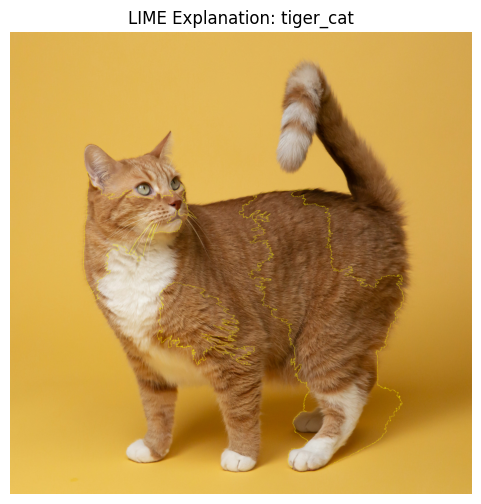


Loading flower.jpg...
Running LIME...


  0%|          | 0/500 [00:00<?, ?it/s]

Done!
Predicted: vase


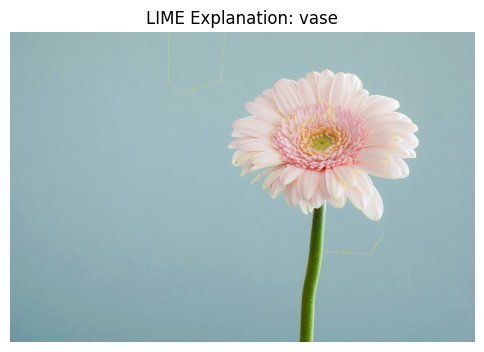


Loading avocado.jpg...
Running LIME...


  0%|          | 0/500 [00:00<?, ?it/s]

Done!
Predicted: cucumber


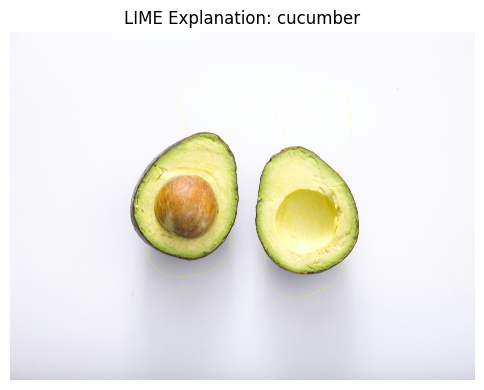


Loading car.jpg...
Running LIME...


  0%|          | 0/500 [00:00<?, ?it/s]

Done!
Predicted: minivan


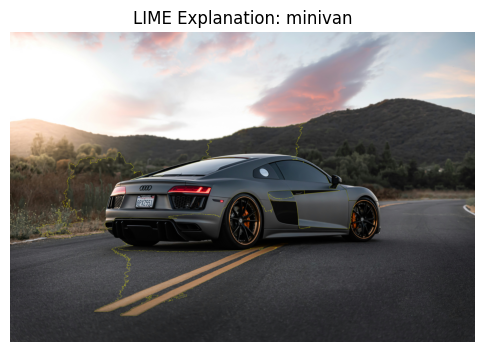

In [11]:
from tqdm.notebook import tqdm
from lime import lime_image
from skimage.segmentation import slic

explainer = lime_image.LimeImageExplainer()

for path in tqdm(image_paths, desc="Images"):

    print(f"\nLoading {path}...")
    img = np.array(Image.open(path).convert("RGB"))

    print("Running LIME...")
    explanation = explainer.explain_instance(
        img,
        predict_fn,
        top_labels=3,
        num_samples=500,
        segmentation_fn=lambda x: slic(x, n_segments=50)
    )

    print("Done!")
    
    
    # Get top prediction
    top_label = explanation.top_labels[0]
    print("Predicted:", idx2label[top_label])
    
    # Get explanation mask
    temp, mask = explanation.get_image_and_mask(
        top_label,
        positive_only=True,
        num_features=5,
        hide_rest=False
    )
    
    # Plot
    plt.figure(figsize=(6,6))
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME Explanation: {idx2label[top_label]}")
    plt.axis('off')
    plt.show()

In [ ]:
!git 